In [5]:
import cv2
import matplotlib.pyplot as plt
import os


In [7]:
dataset = 'plant_dataset'
files = os.listdir(dataset)
files



['video_A.mp4',
 'Video_B.mp4',
 'Video_C.mp4',
 'Video_D.mp4',
 'Video_E.mp4',
 'Video_F.mp4',
 'Video_g.mp4',
 'Video_h.mp4',
 'Video_i.mp4',
 'Video_j.mp4',
 'Video_k.mp4',
 'Video_L.mp4',
 'Video_m.mp4',
 'Video_n.mp4',
 'Video_p.mp4',
 'Video_q.mp4',
 'Video_r.mp4',
 'Video_s.mp4',
 'Video_t.mp4',
 'Video_u.mp4',
 'Video_v.mp4']

# Extracting images from videos

In [12]:
import cv2
import os

video_folder = "plant_dataset"
output_folder = "extracted_images"

os.makedirs(output_folder, exist_ok=True)

video_files = os.listdir(video_folder)

for video in video_files:
    video_path = os.path.join(video_folder, video)

    cap = cv2.VideoCapture(video_path)

    frame_id = 0
    saved_count = 0

    while True:
        success, frame = cap.read()

        if not success:
            break

        # Saves every 10th frame 
        if frame_id % 10 == 0:
            filename = f"{video.split('.')[0]}_frame{saved_count}.jpg"
            cv2.imwrite(os.path.join(output_folder, filename), frame)
            saved_count += 1

        frame_id += 1

    cap.release()

print("Done extracting image")

Done extracting image


# Lbp(Local Binary Patterns Extraction

In [13]:
!pip install scikit-image

In [14]:
import cv2
import os
import numpy as np
from skimage.feature import local_binary_pattern

In [15]:
#set lbp parameters
radius = 1
n_points = 8 * radius

In [21]:
#loading extracted images
image_folder = "extracted_images"
data = []
labels = []
print("Total images:", len(os.listdir(image_folder)))

Total images: 1446


# Extract LBP Features + Show Sample Histograms

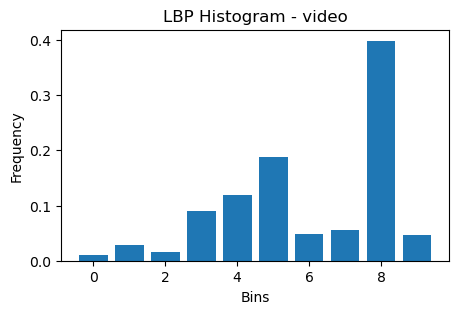

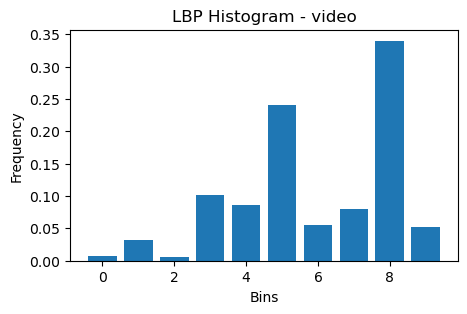

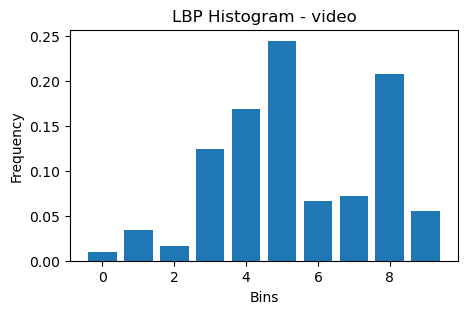

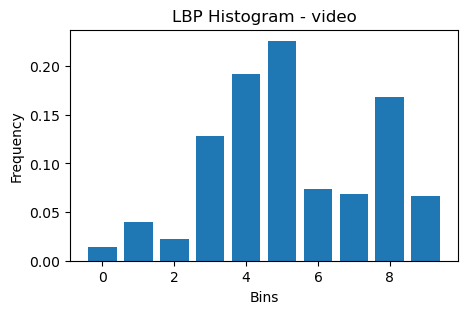

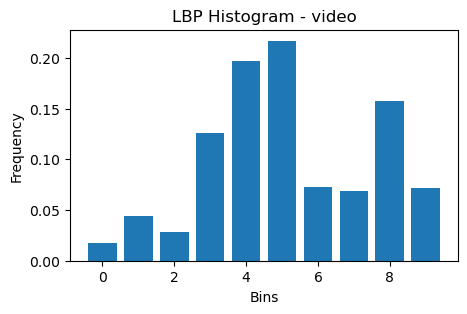

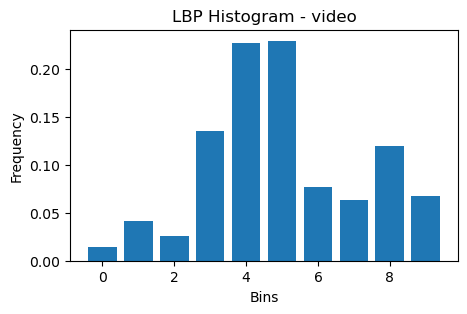

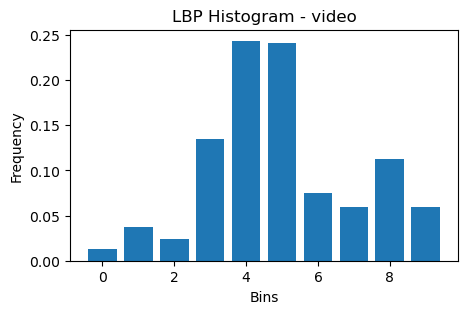

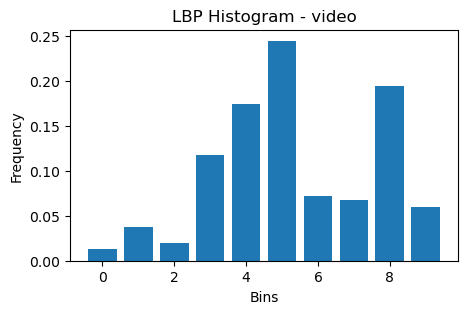

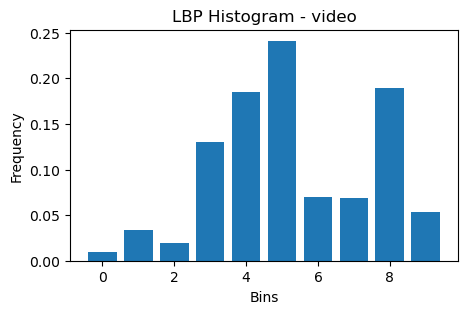

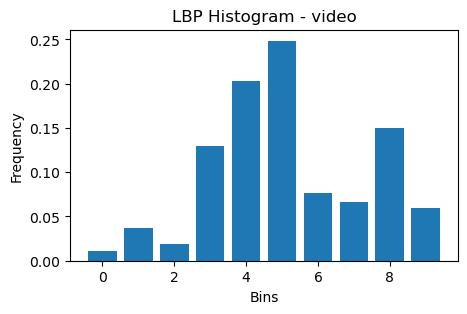

In [ ]:
data = []
labels = []

count = 0
max_show = 10  # show only first 10 histograms

for img_name in os.listdir(image_folder):
    img_path = os.path.join(image_folder, img_name)

    img = cv2.imread(img_path, 0)  # grayscale

    if img is None:
        continue

    # LBP extraction
    lbp = local_binary_pattern(img, n_points, radius, method="uniform")

    # histogram
    hist, _ = np.histogram(
        lbp.ravel(),
        bins=np.arange(0, n_points + 3),
        range=(0, n_points + 2)
    )

    # normalize
    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-6)

    data.append(hist)

    # label from filename
    label = img_name.split("_")[0]
    labels.append(label)

    # show histogram for first few images only
    if count < max_show:
        plt.figure(figsize=(5,3))
        plt.bar(range(len(hist)), hist)
        plt.title(f"LBP Histogram - {label}")
        plt.xlabel("Bins")
        plt.ylabel("Frequency")
        plt.show()

        count += 1

Image: video_A_frame0.jpg
Extracted Label: video
Feature Vector Length: 10
-----------------------------


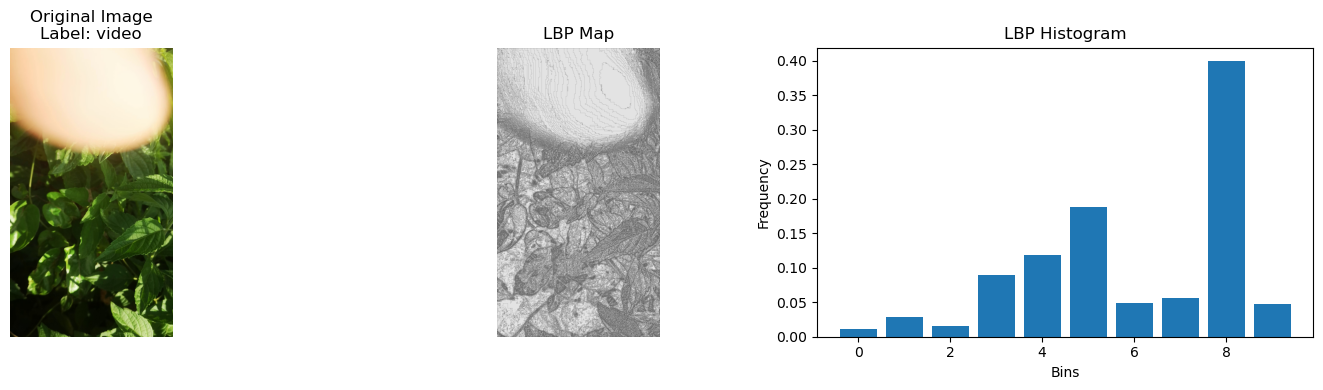

Image: video_A_frame1.jpg
Extracted Label: video
Feature Vector Length: 10
-----------------------------


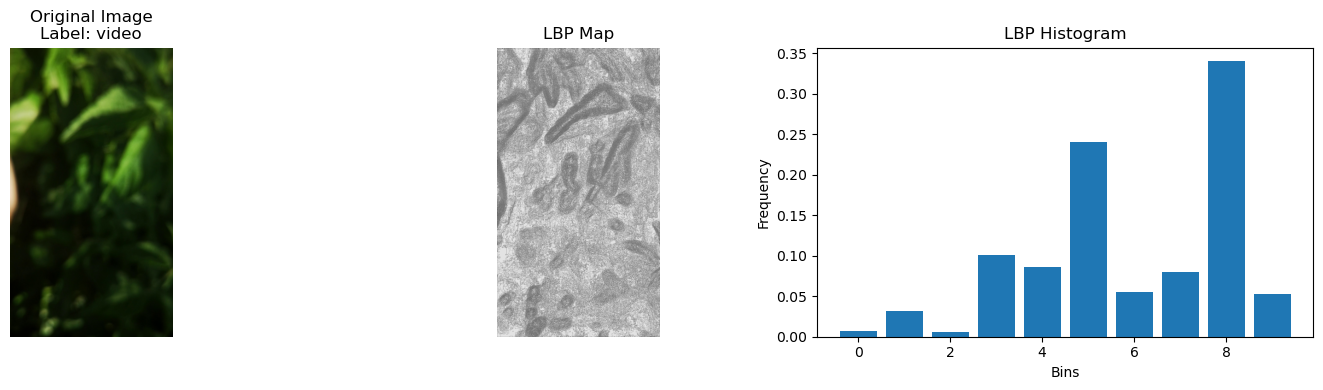

Image: video_A_frame10.jpg
Extracted Label: video
Feature Vector Length: 10
-----------------------------


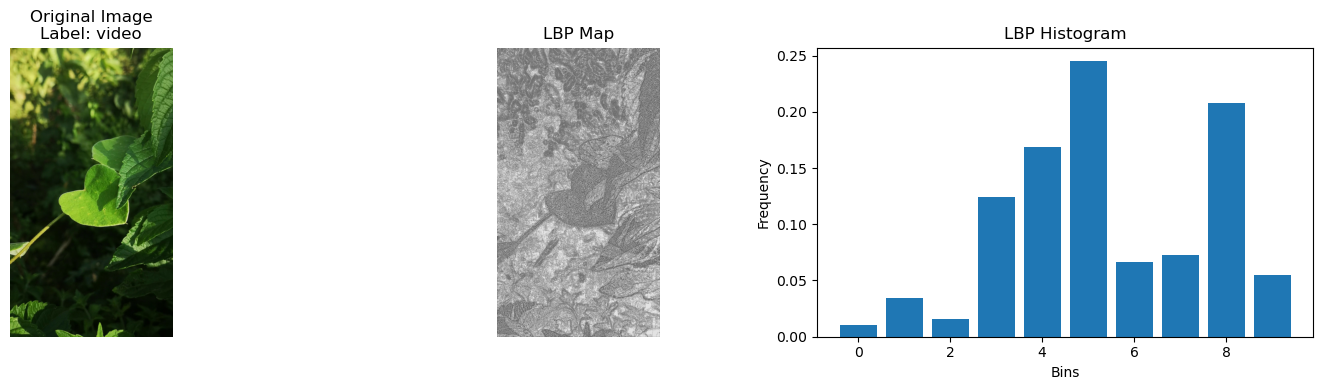

Image: video_A_frame11.jpg
Extracted Label: video
Feature Vector Length: 10
-----------------------------


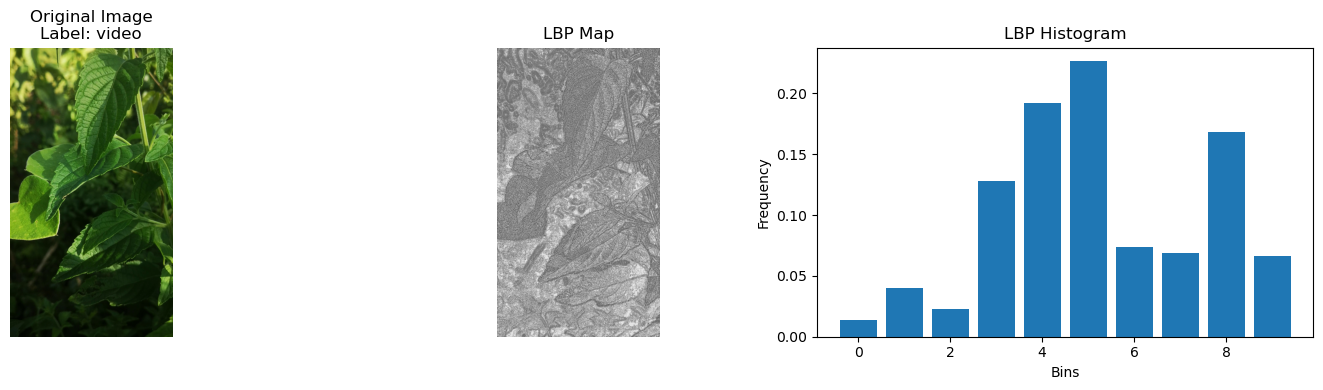

Image: video_A_frame12.jpg
Extracted Label: video
Feature Vector Length: 10
-----------------------------


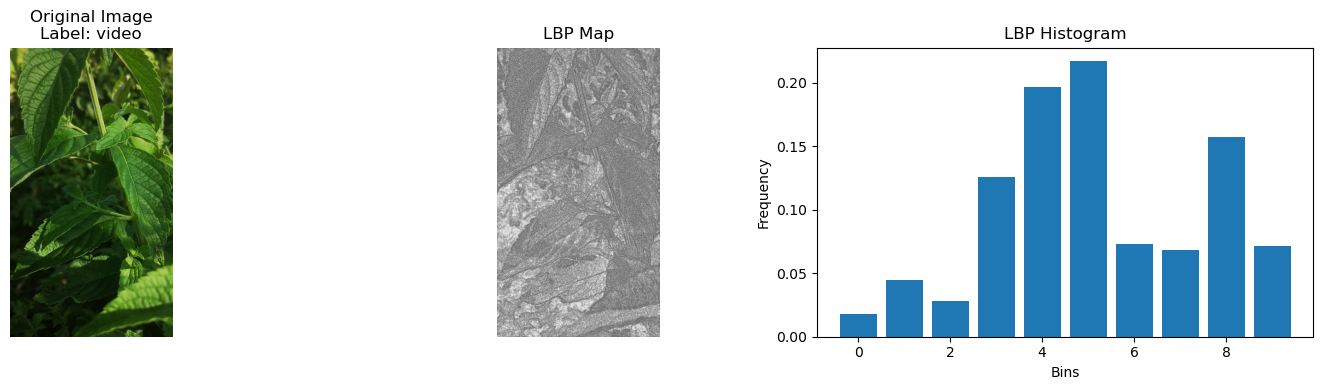

Image: video_A_frame13.jpg
Extracted Label: video
Feature Vector Length: 10
-----------------------------


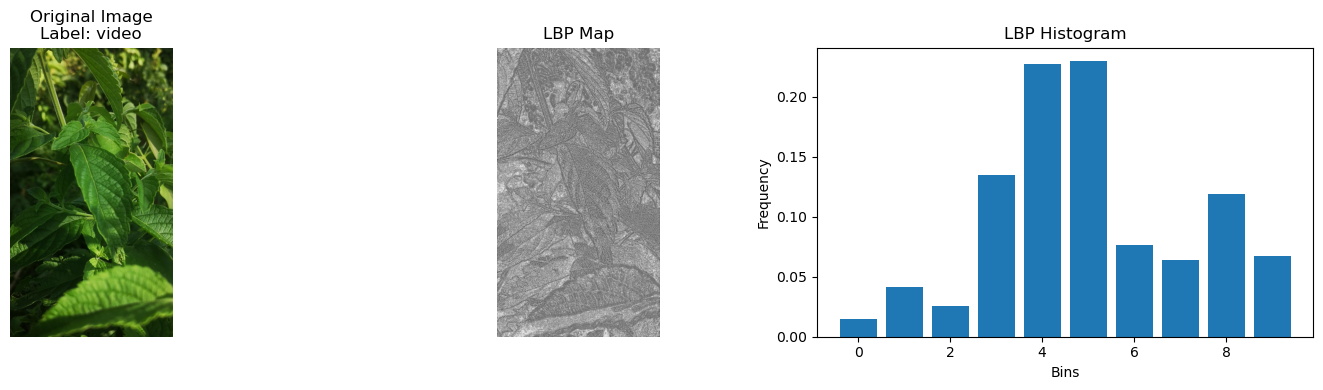

Image: video_A_frame14.jpg
Extracted Label: video
Feature Vector Length: 10
-----------------------------


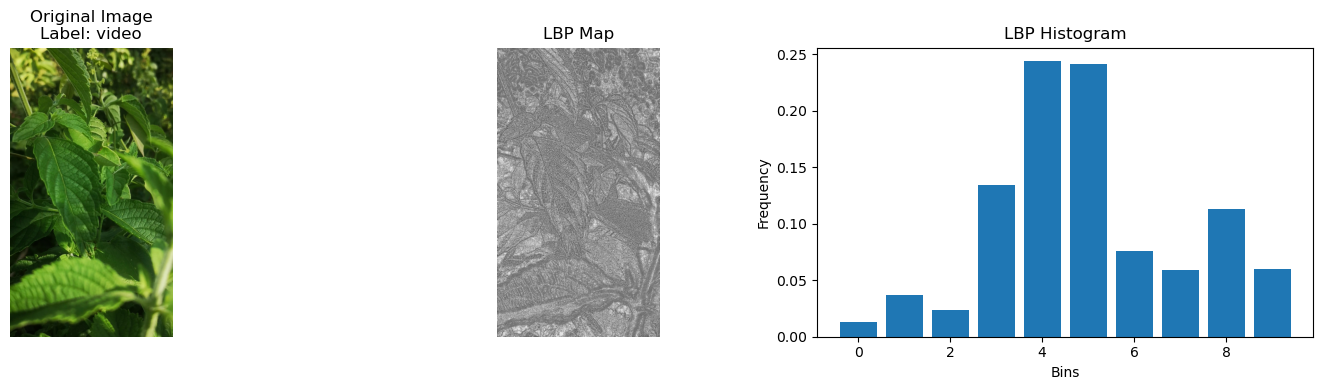

Image: video_A_frame15.jpg
Extracted Label: video
Feature Vector Length: 10
-----------------------------


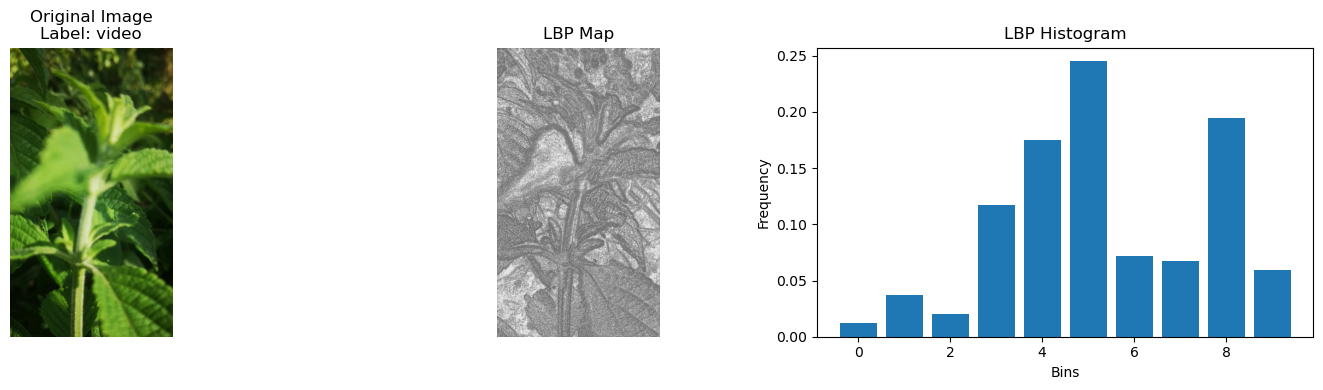

Image: video_A_frame16.jpg
Extracted Label: video
Feature Vector Length: 10
-----------------------------


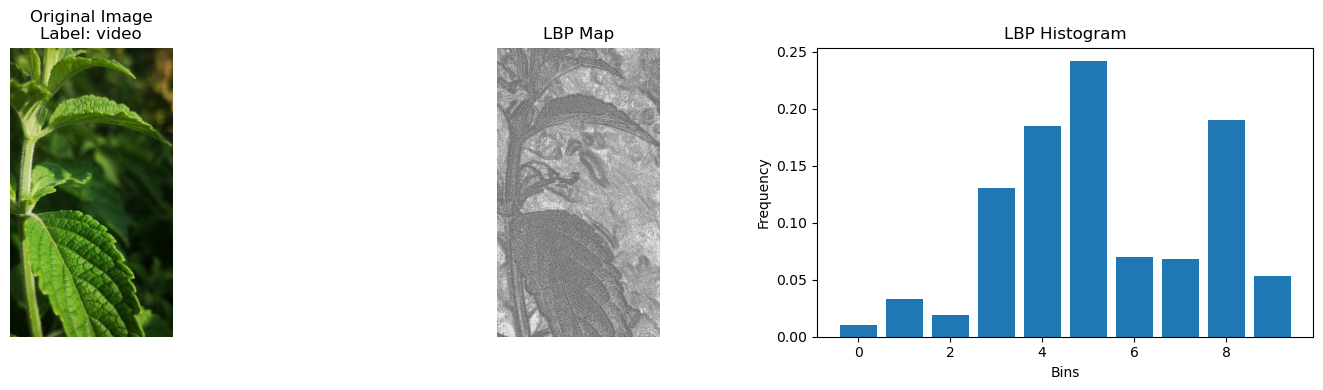

Image: video_A_frame17.jpg
Extracted Label: video
Feature Vector Length: 10
-----------------------------


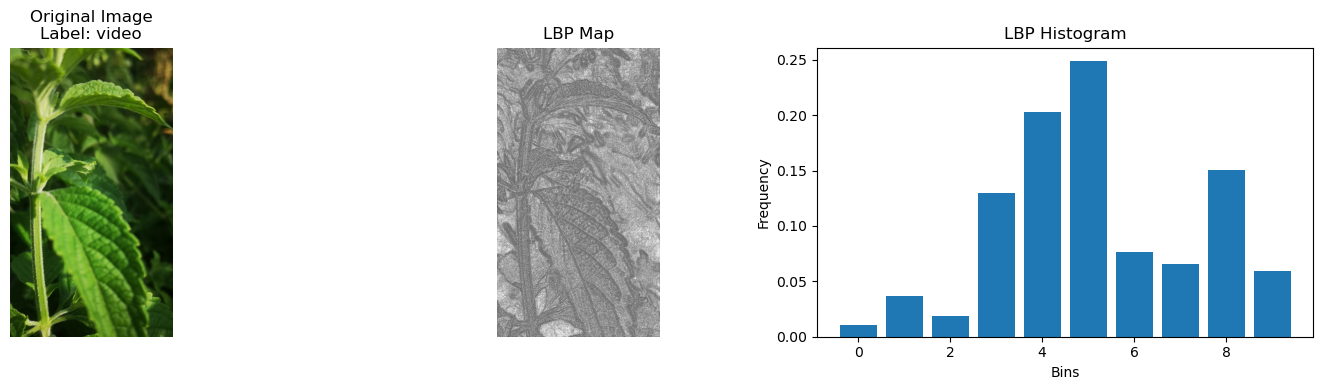


===== DATA SUMMARY =====
Total Images Processed: 1446
Total Labels: 1446
Unique Classes: {'video', 'Video'}


In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import local_binary_pattern

# =========================
# CONFIGURATION (IMPORTANT)
# =========================
image_folder = "extracted_images"

radius = 1
n_points = 8 * radius

data = []
labels = []

count = 0
max_show = 10  # show only first 10 samples

# =========================
# LOOP THROUGH IMAGES
# =========================
for img_name in os.listdir(image_folder):
    img_path = os.path.join(image_folder, img_name)

    # read image (color for display)
    img_color = cv2.imread(img_path)

    if img_color is None:
        continue

    # convert to grayscale for LBP
    img_gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)

    # =========================
    # LBP FEATURE EXTRACTION
    # =========================
    lbp = local_binary_pattern(img_gray, n_points, radius, method="uniform")

    hist, _ = np.histogram(
        lbp.ravel(),
        bins=np.arange(0, n_points + 3),
        range=(0, n_points + 2)
    )

    # normalize histogram
    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-6)

    data.append(hist)

    # =========================
    # LABEL EXTRACTION
    # =========================
    label = img_name.split("_")[0]
    labels.append(label)

    # =========================
    # VISUALIZATION (ONLY FIRST 10)
    # =========================
    if count < max_show:

        # KEY MATCH INFO (for report understanding)
        print("Image:", img_name)
        print("Extracted Label:", label)
        print("Feature Vector Length:", len(hist))
        print("-----------------------------")

        plt.figure(figsize=(15, 4))

        # 1. Original Image
        plt.subplot(1, 3, 1)
        plt.imshow(cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB))
        plt.title(f"Original Image\nLabel: {label}")
        plt.axis("off")

        # 2. LBP Map
        plt.subplot(1, 3, 2)
        plt.imshow(lbp, cmap="gray")
        plt.title("LBP Map")
        plt.axis("off")

        # 3. Histogram
        plt.subplot(1, 3, 3)
        plt.bar(range(len(hist)), hist)
        plt.title("LBP Histogram")
        plt.xlabel("Bins")
        plt.ylabel("Frequency")

        plt.tight_layout()
        plt.show()

        count += 1

# =========================
# FINAL SUMMARY CHECK
# =========================
print("\n===== DATA SUMMARY =====")
print("Total Images Processed:", len(data))
print("Total Labels:", len(labels))
print("Unique Classes:", set(labels))